In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv("./creditcard.csv")

## 1. Understanding the dataset

In [3]:
df.shape

(284807, 31)

In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(1081)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [10]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.759088e-12,-8.251210e-13,-9.655224e-13,8.321417e-13,1.650335e-13,4.248462e-13,-3.054652e-13,8.777941e-14,-1.179734e-12,...,-3.405795e-13,-5.723161e-13,-9.725925e-13,1.464150e-12,-6.987098e-13,-5.617860e-13,3.332081e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 2. Removing the duplicated rows from the dataset

In [11]:
dfcopy = df.copy()

In [12]:
dfcopy.drop_duplicates(inplace=True)

## 3. Outlier analysis

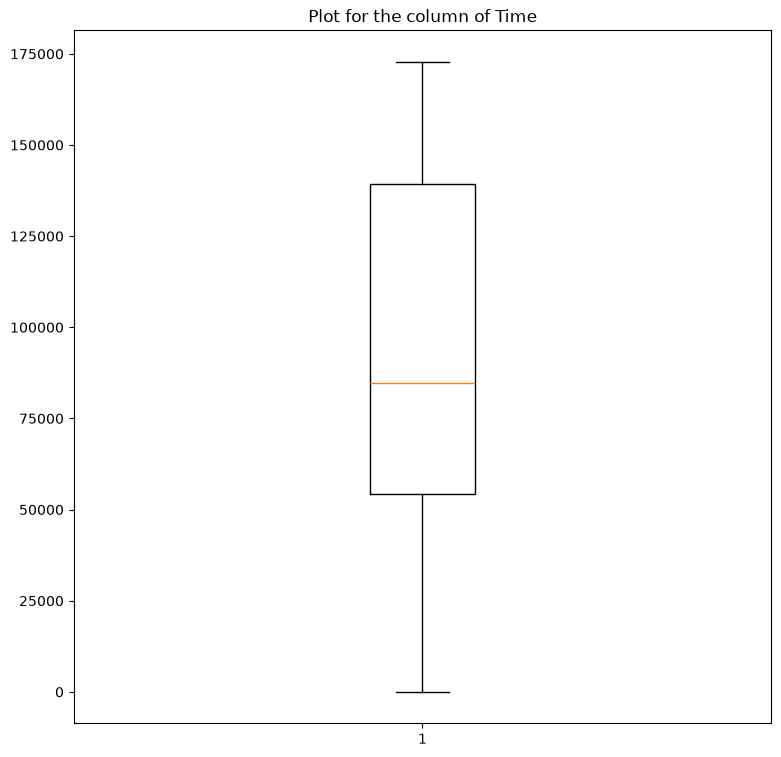

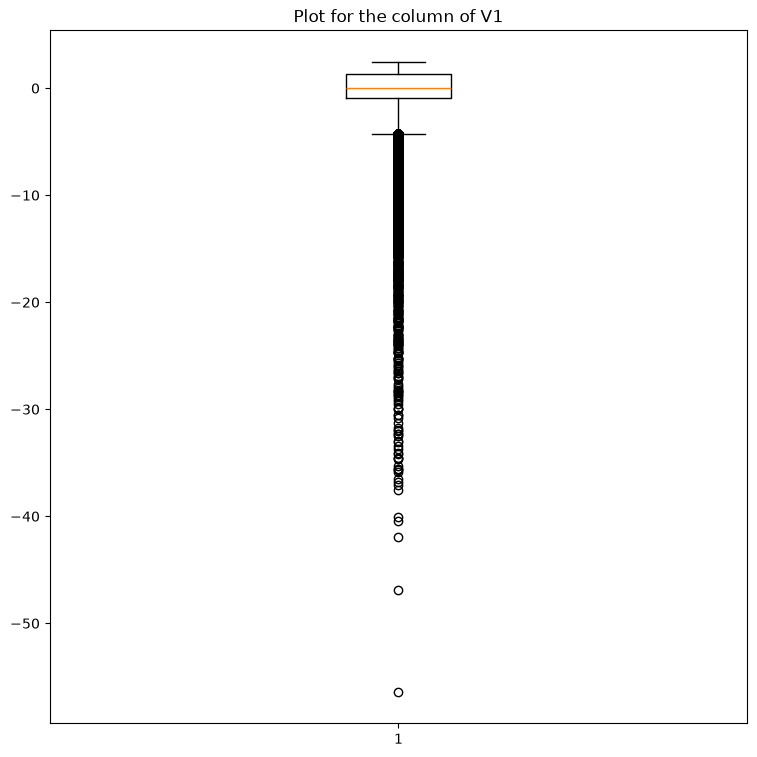

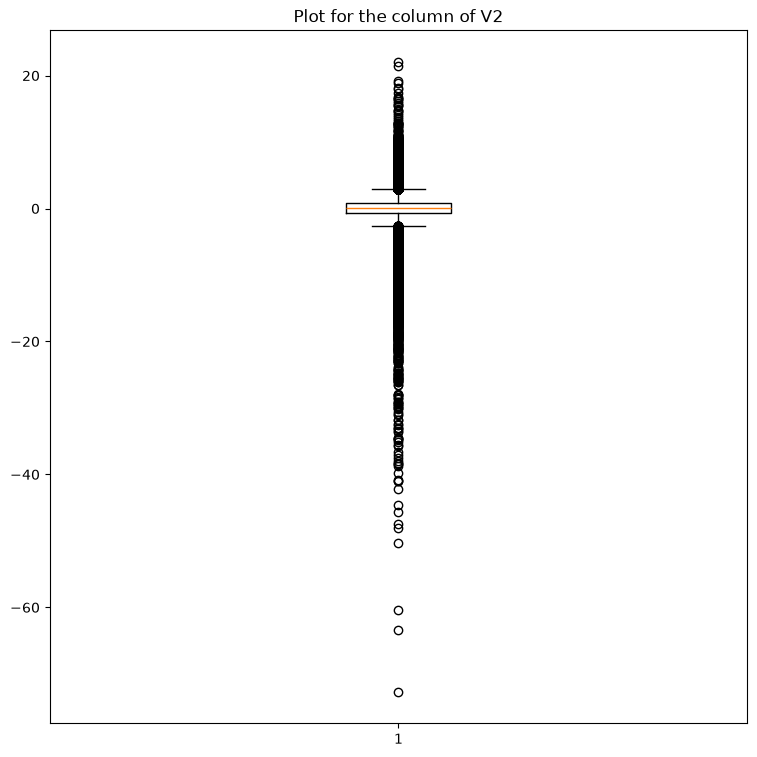

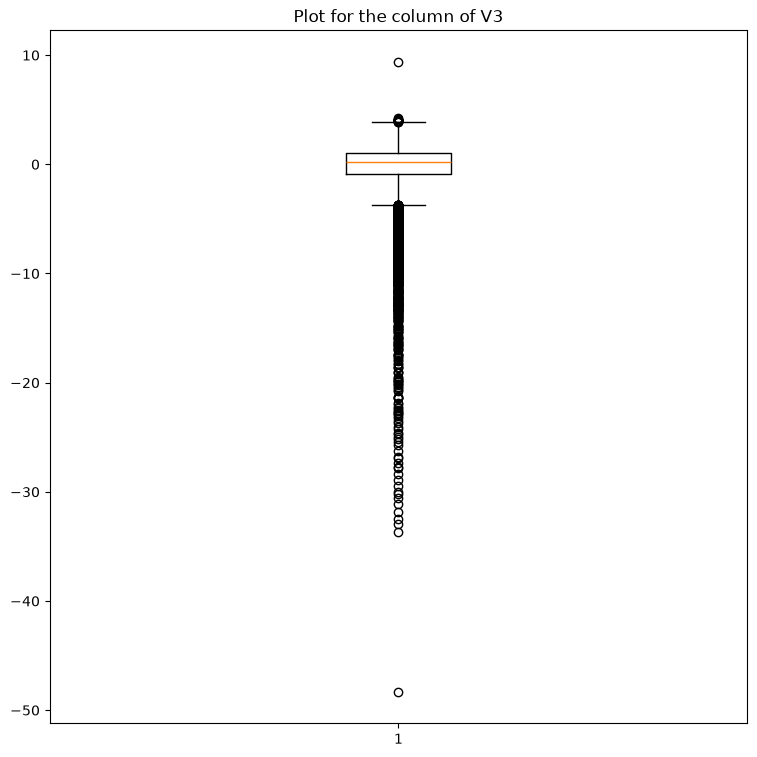

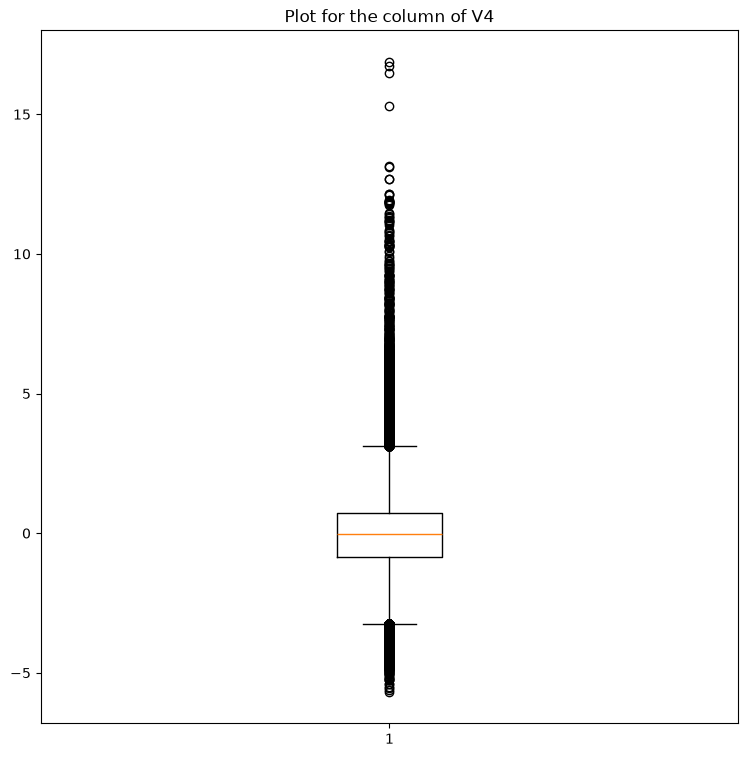

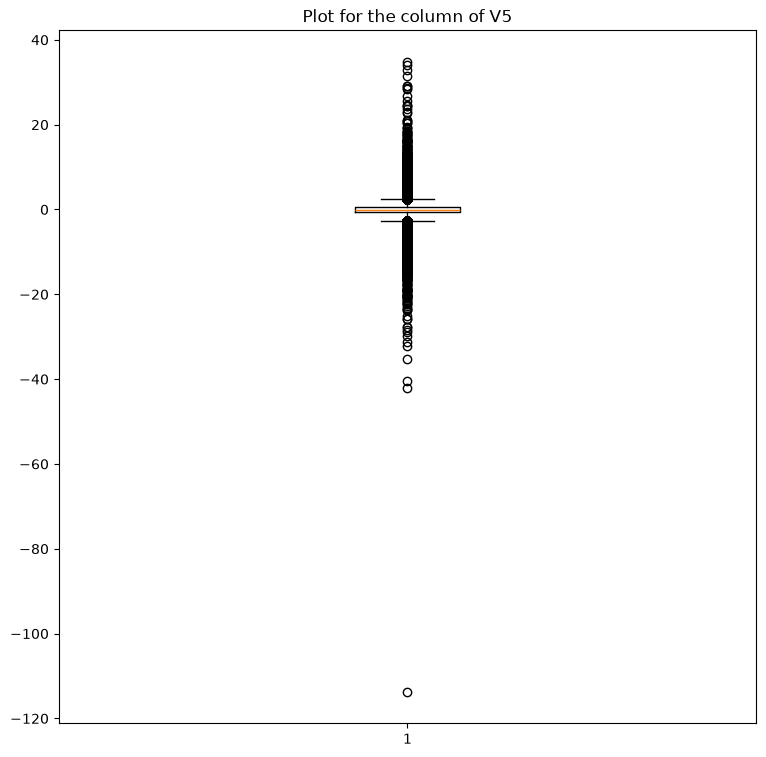

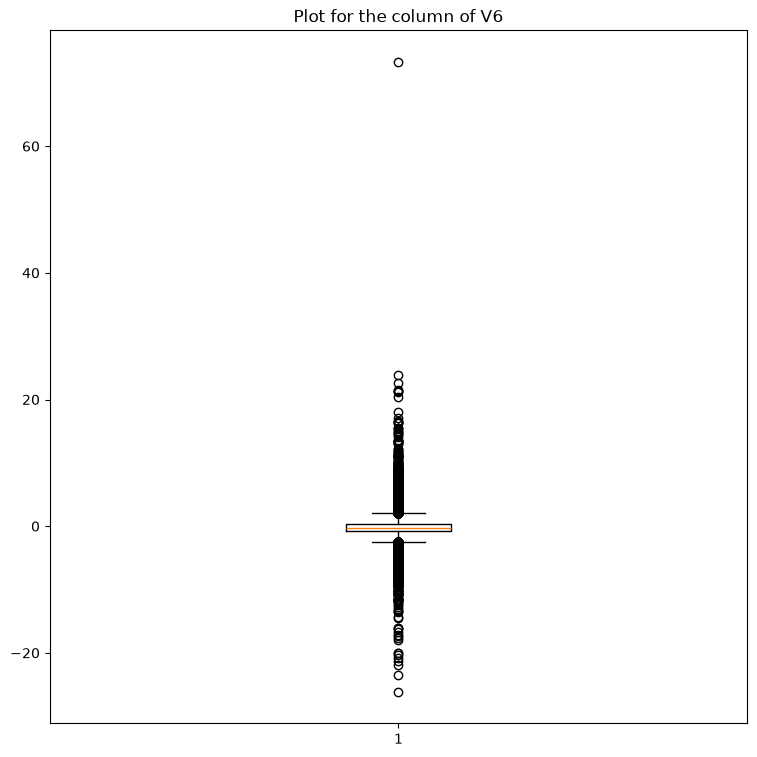

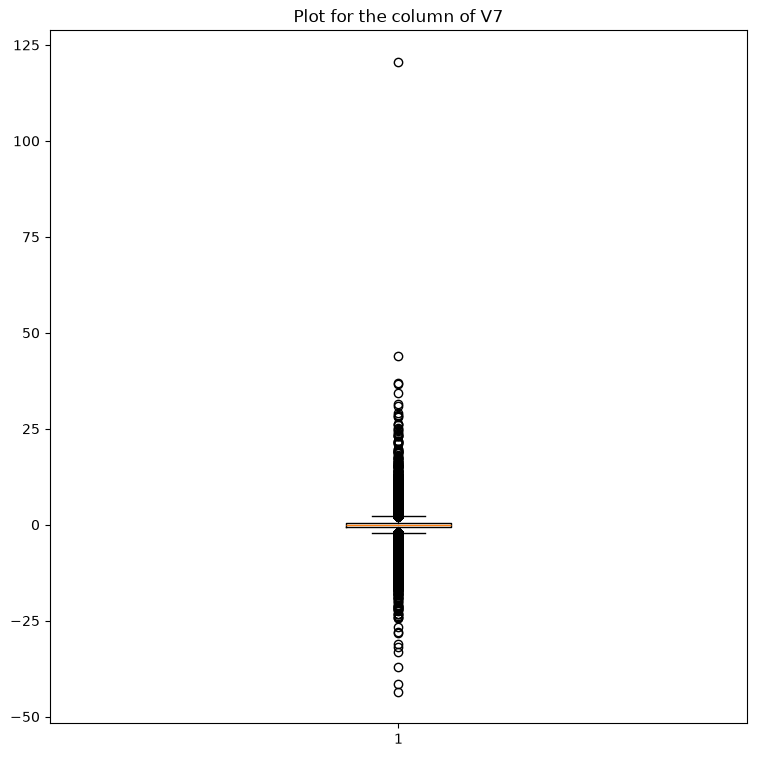

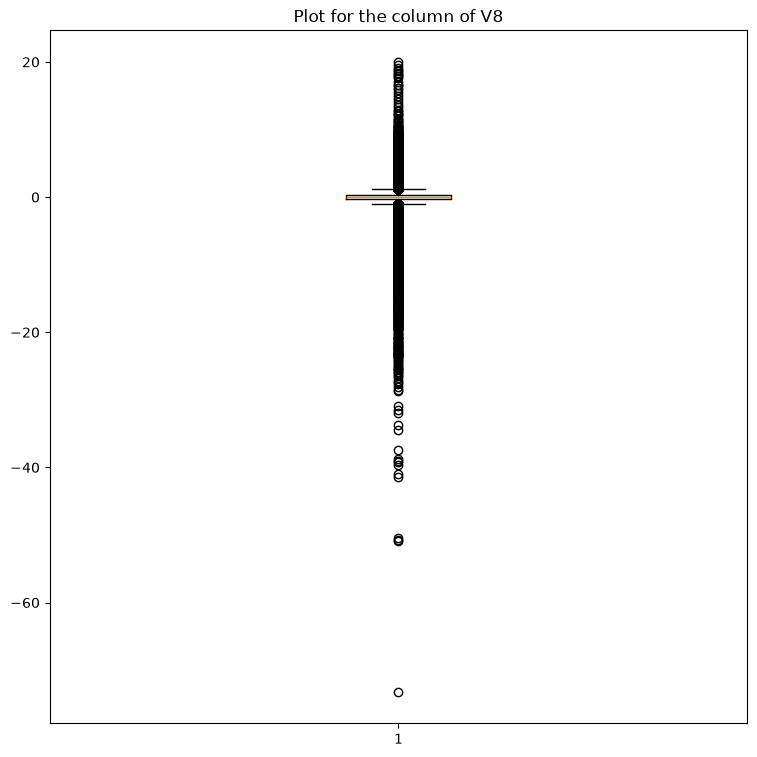

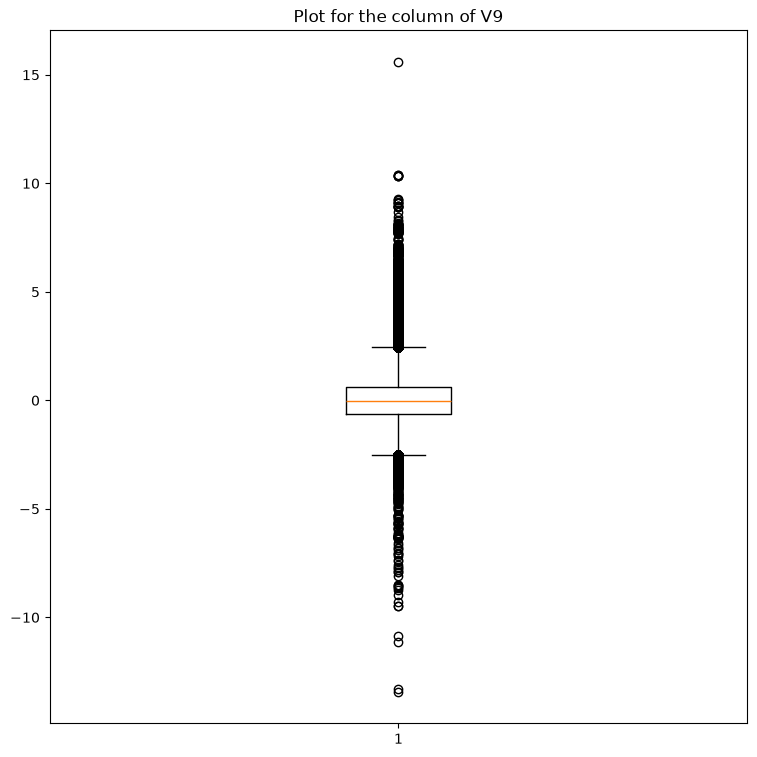

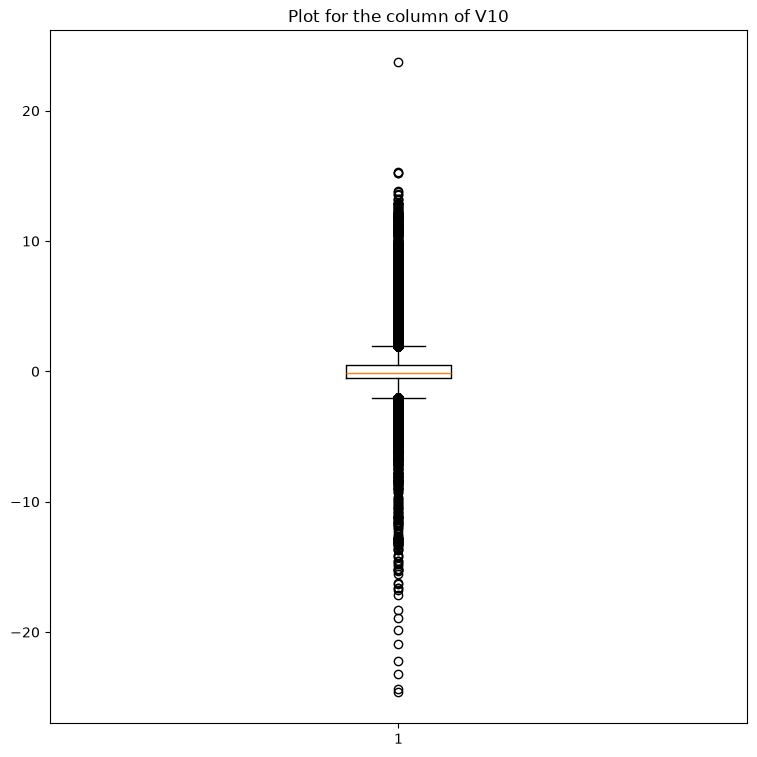

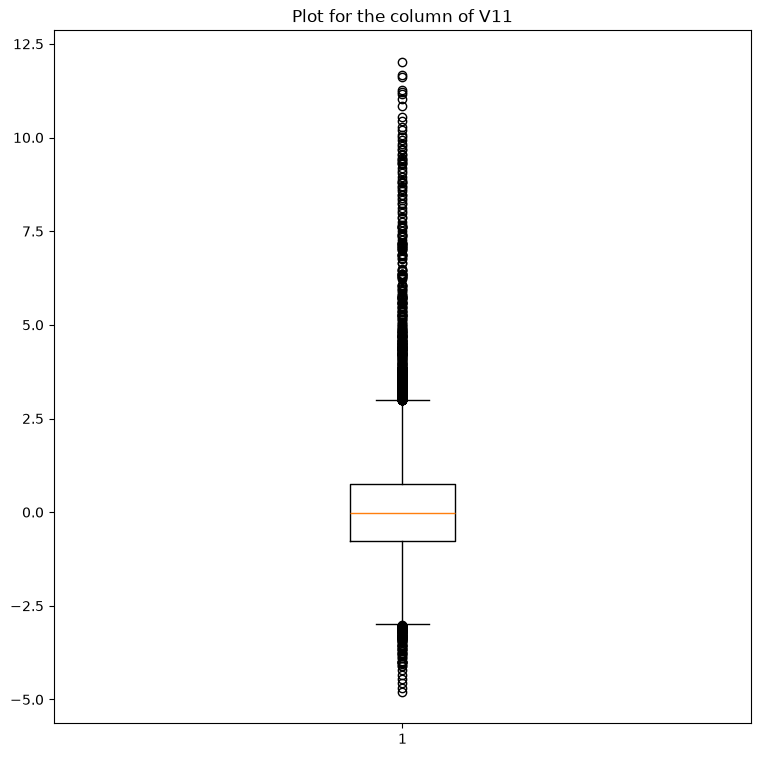

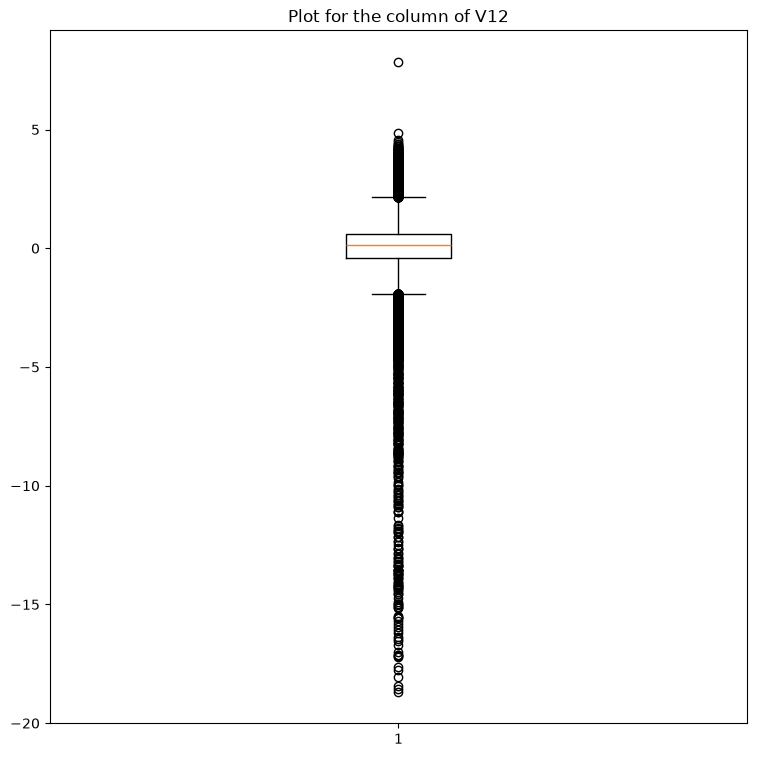

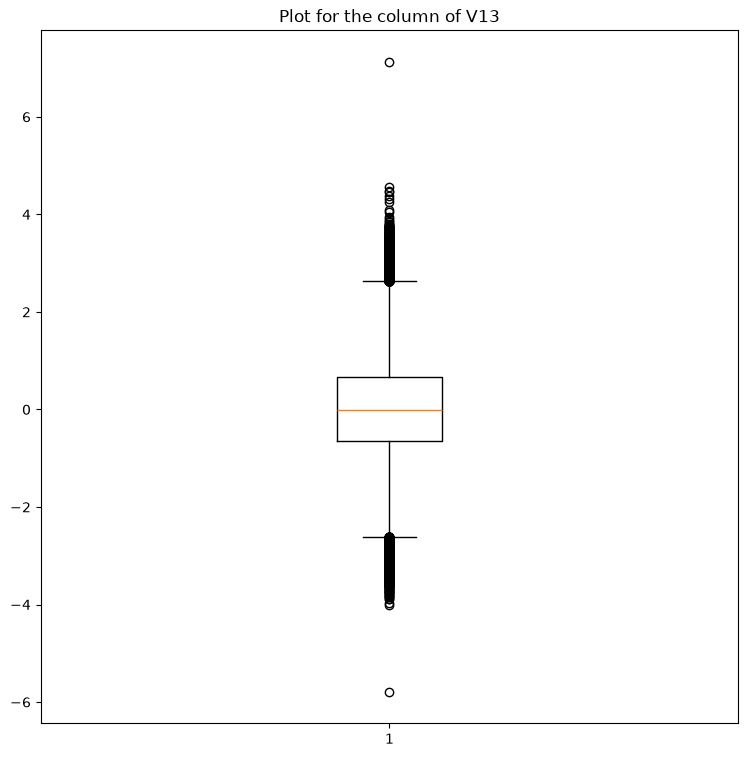

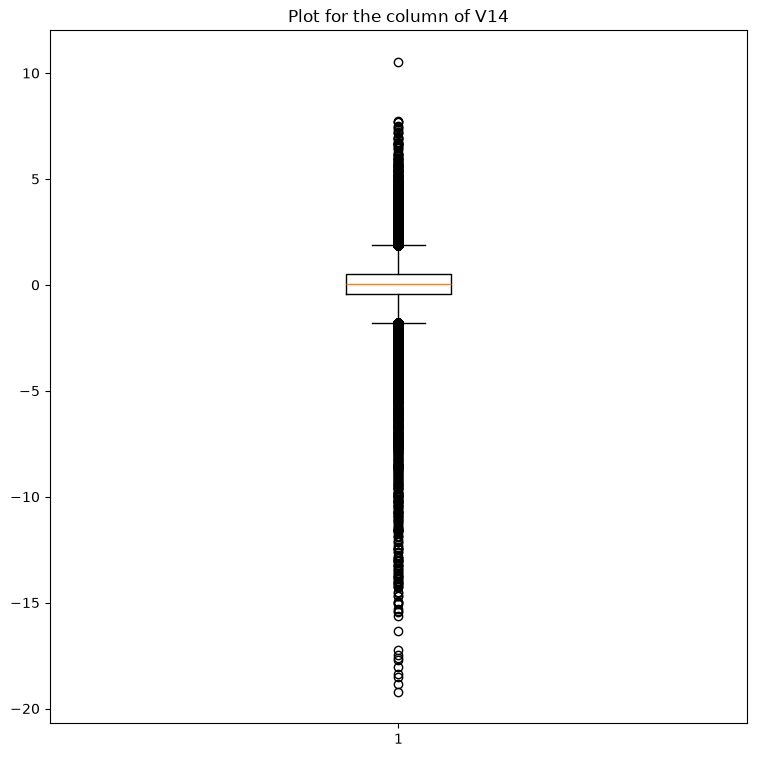

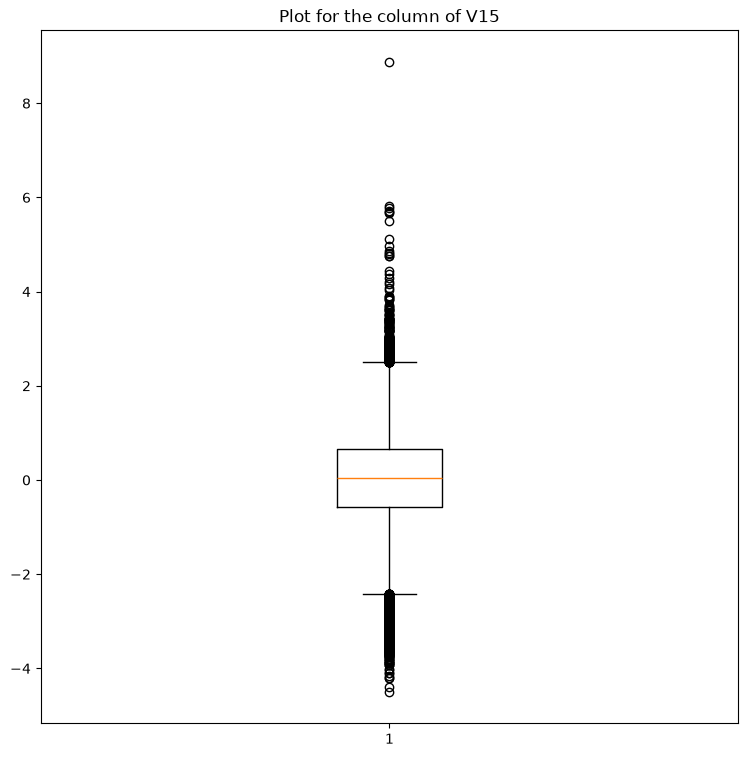

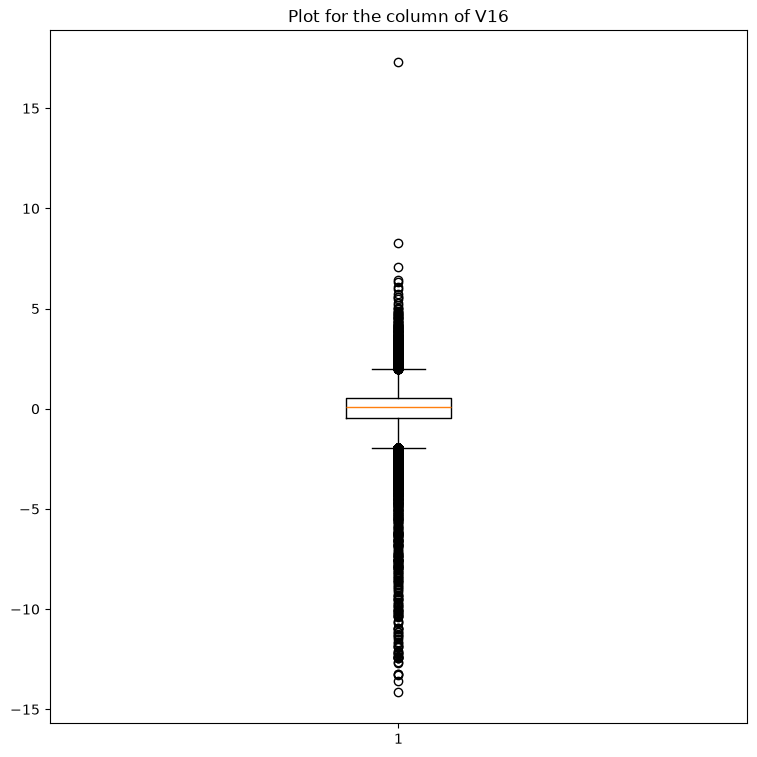

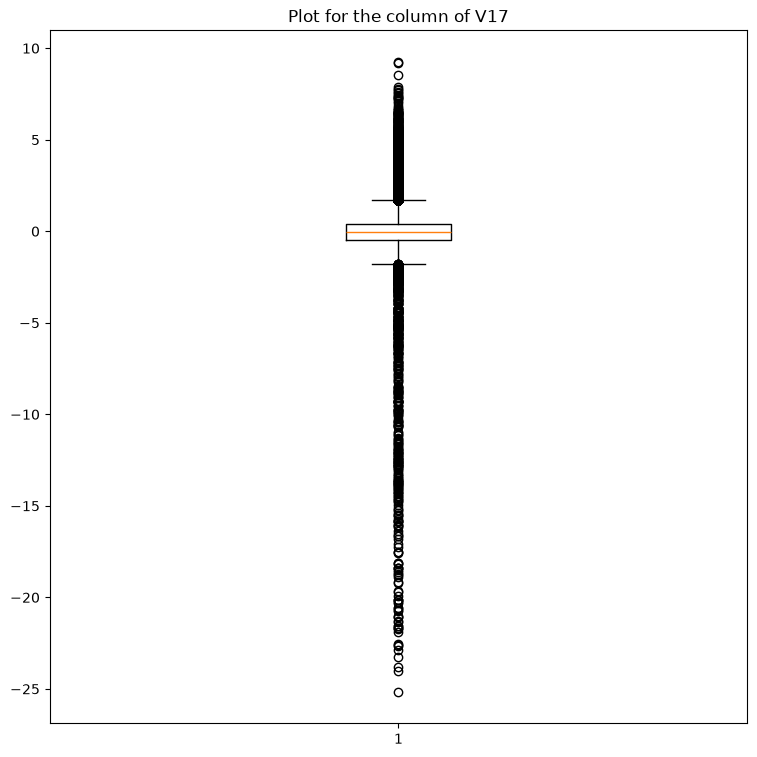

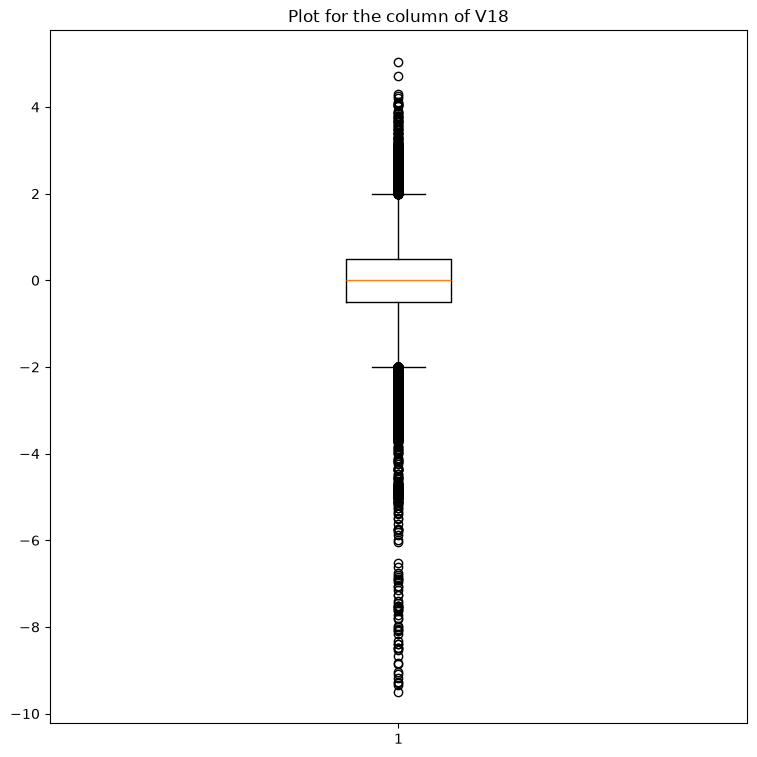

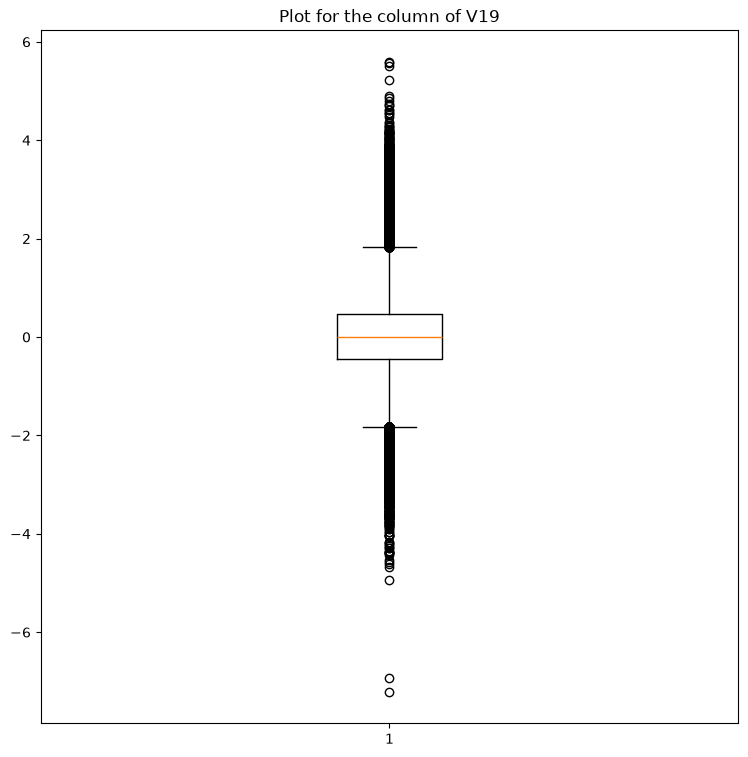

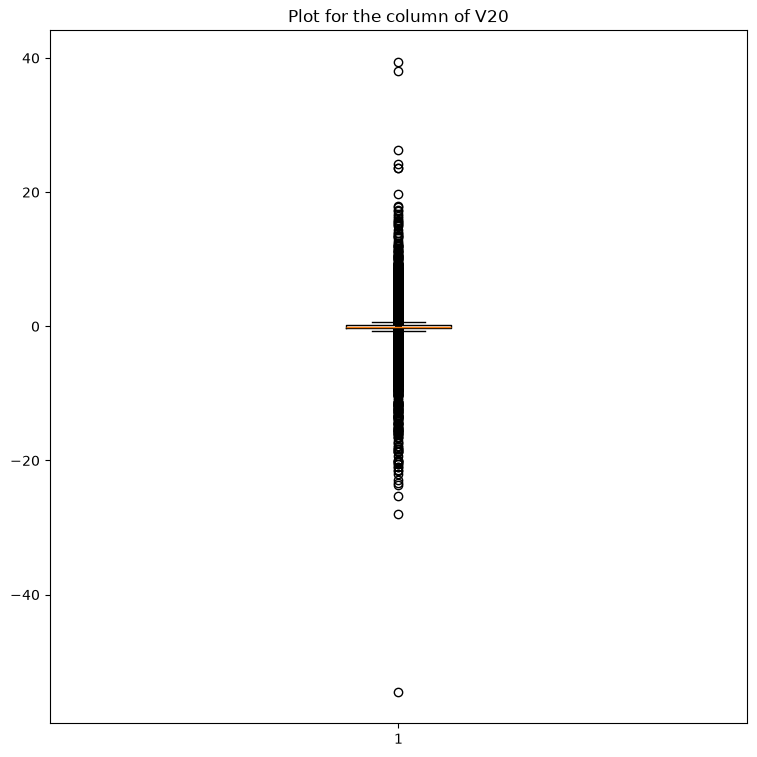

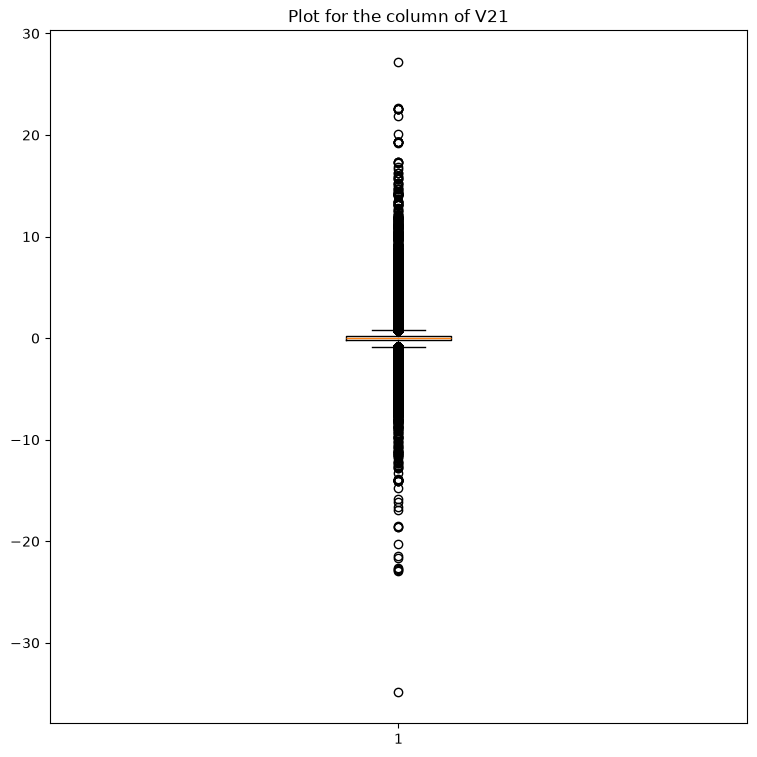

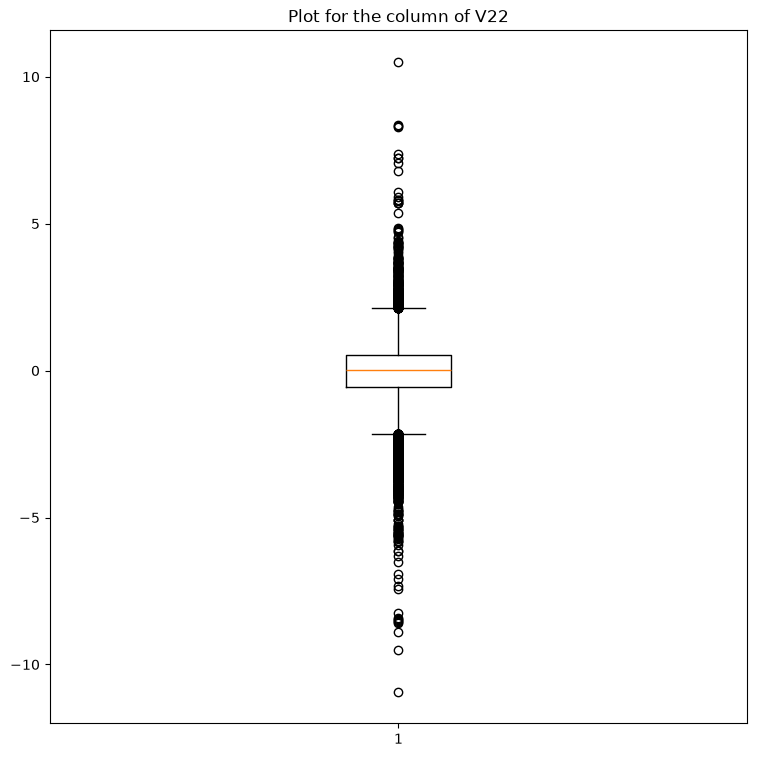

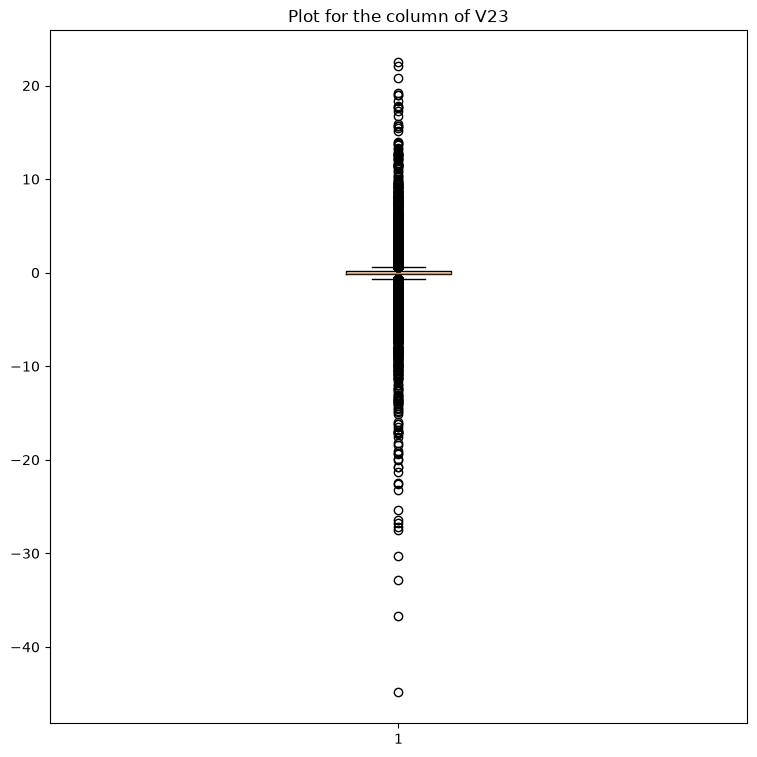

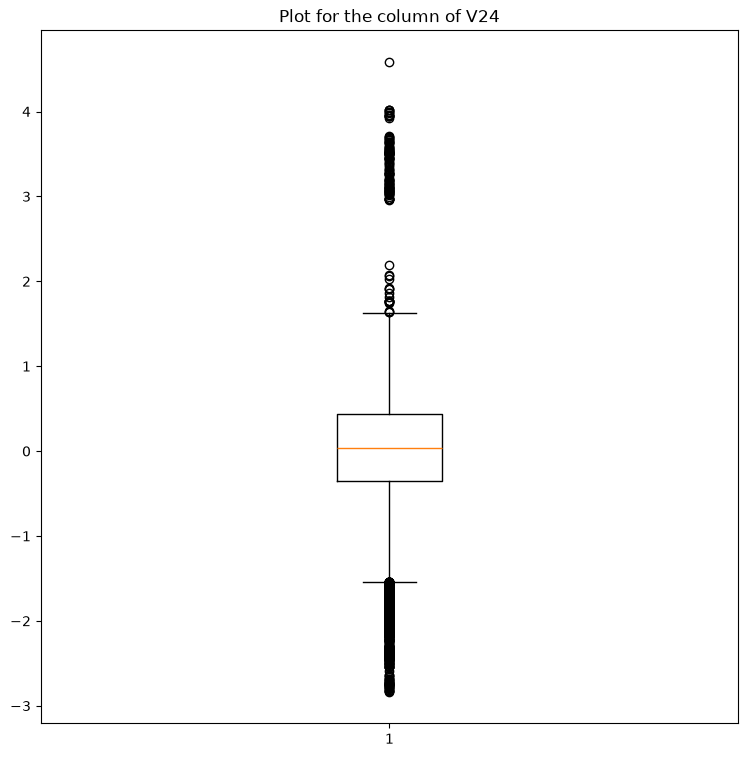

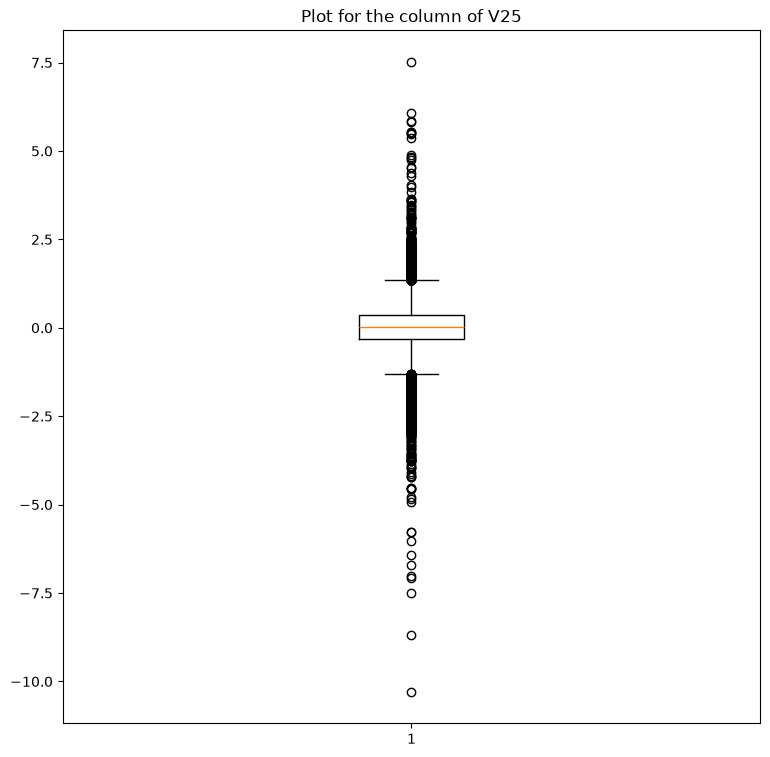

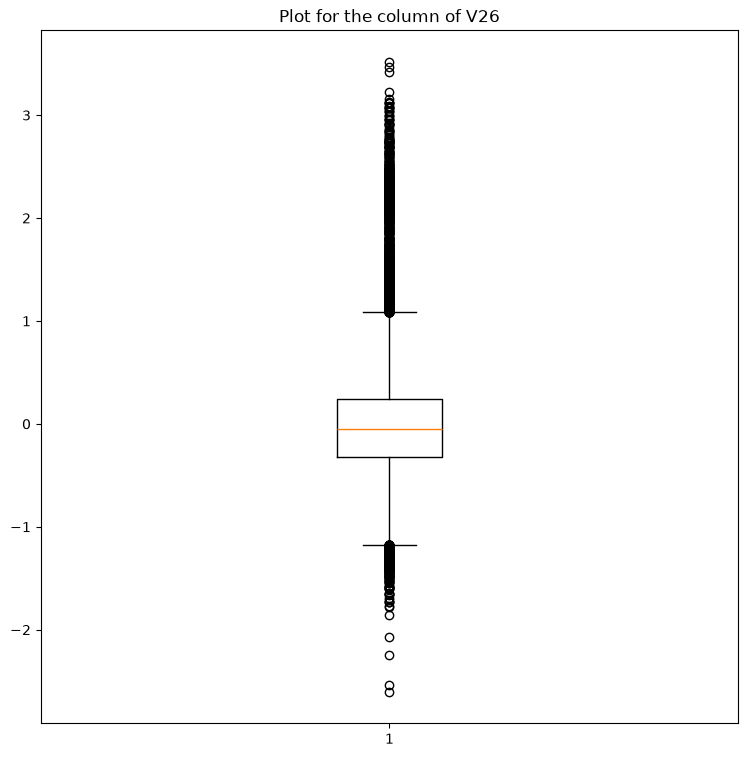

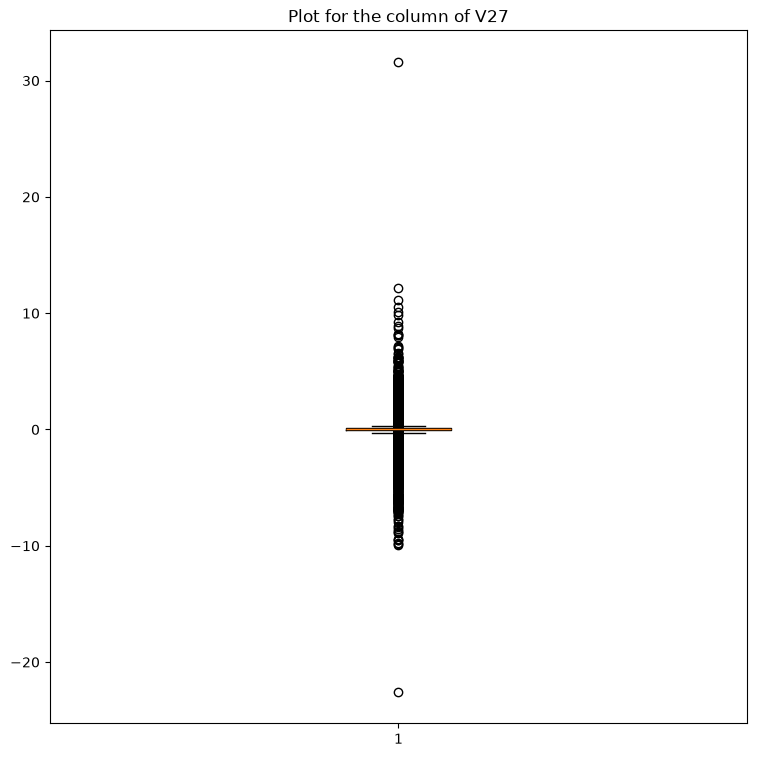

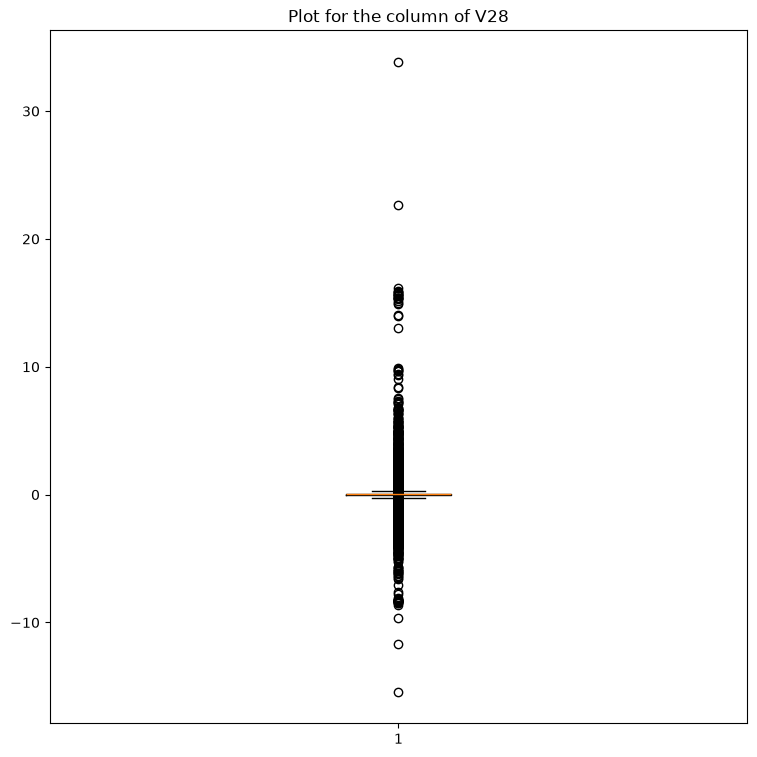

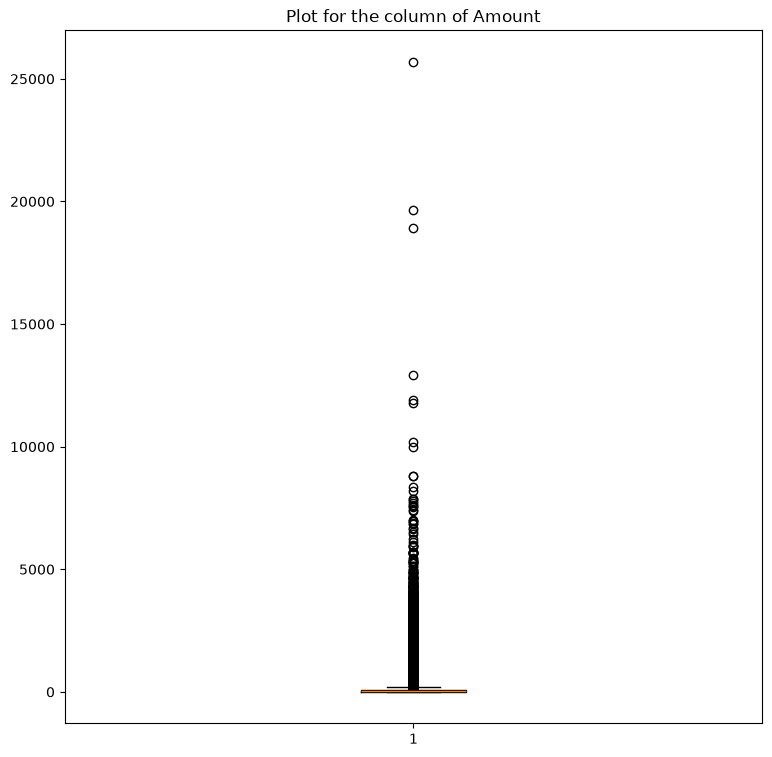

In [13]:
for col in dfcopy.select_dtypes(include="float64"):
    plt.figure(figsize=(9,9))
    plt.boxplot(x=dfcopy[col])
    plt.title(f"Plot for the column of {col}")
    plt.show()

Using IQR method to find perfect number of outliers

In [14]:
iqr_counts = {}

for col in dfcopy.select_dtypes(include="float64"):
    Q1 = dfcopy[col].quantile(0.25)
    Q3 = dfcopy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit, upper_limit = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    iqr_counts[col] = int(((dfcopy[col] < lower_limit) | (dfcopy[col] > upper_limit)).sum())

pd.DataFrame({ "IQR counts": iqr_counts })

,IQR counts
Time,0
V1,6948
V2,13390
V3,3306
V4,11094
V5,12221
V6,22886
V7,8839
V8,23904
V9,8199


Keeping the outliers as it is because handling them may cause distortion in data and removal of some edge cases

## 4. Correlation analysis

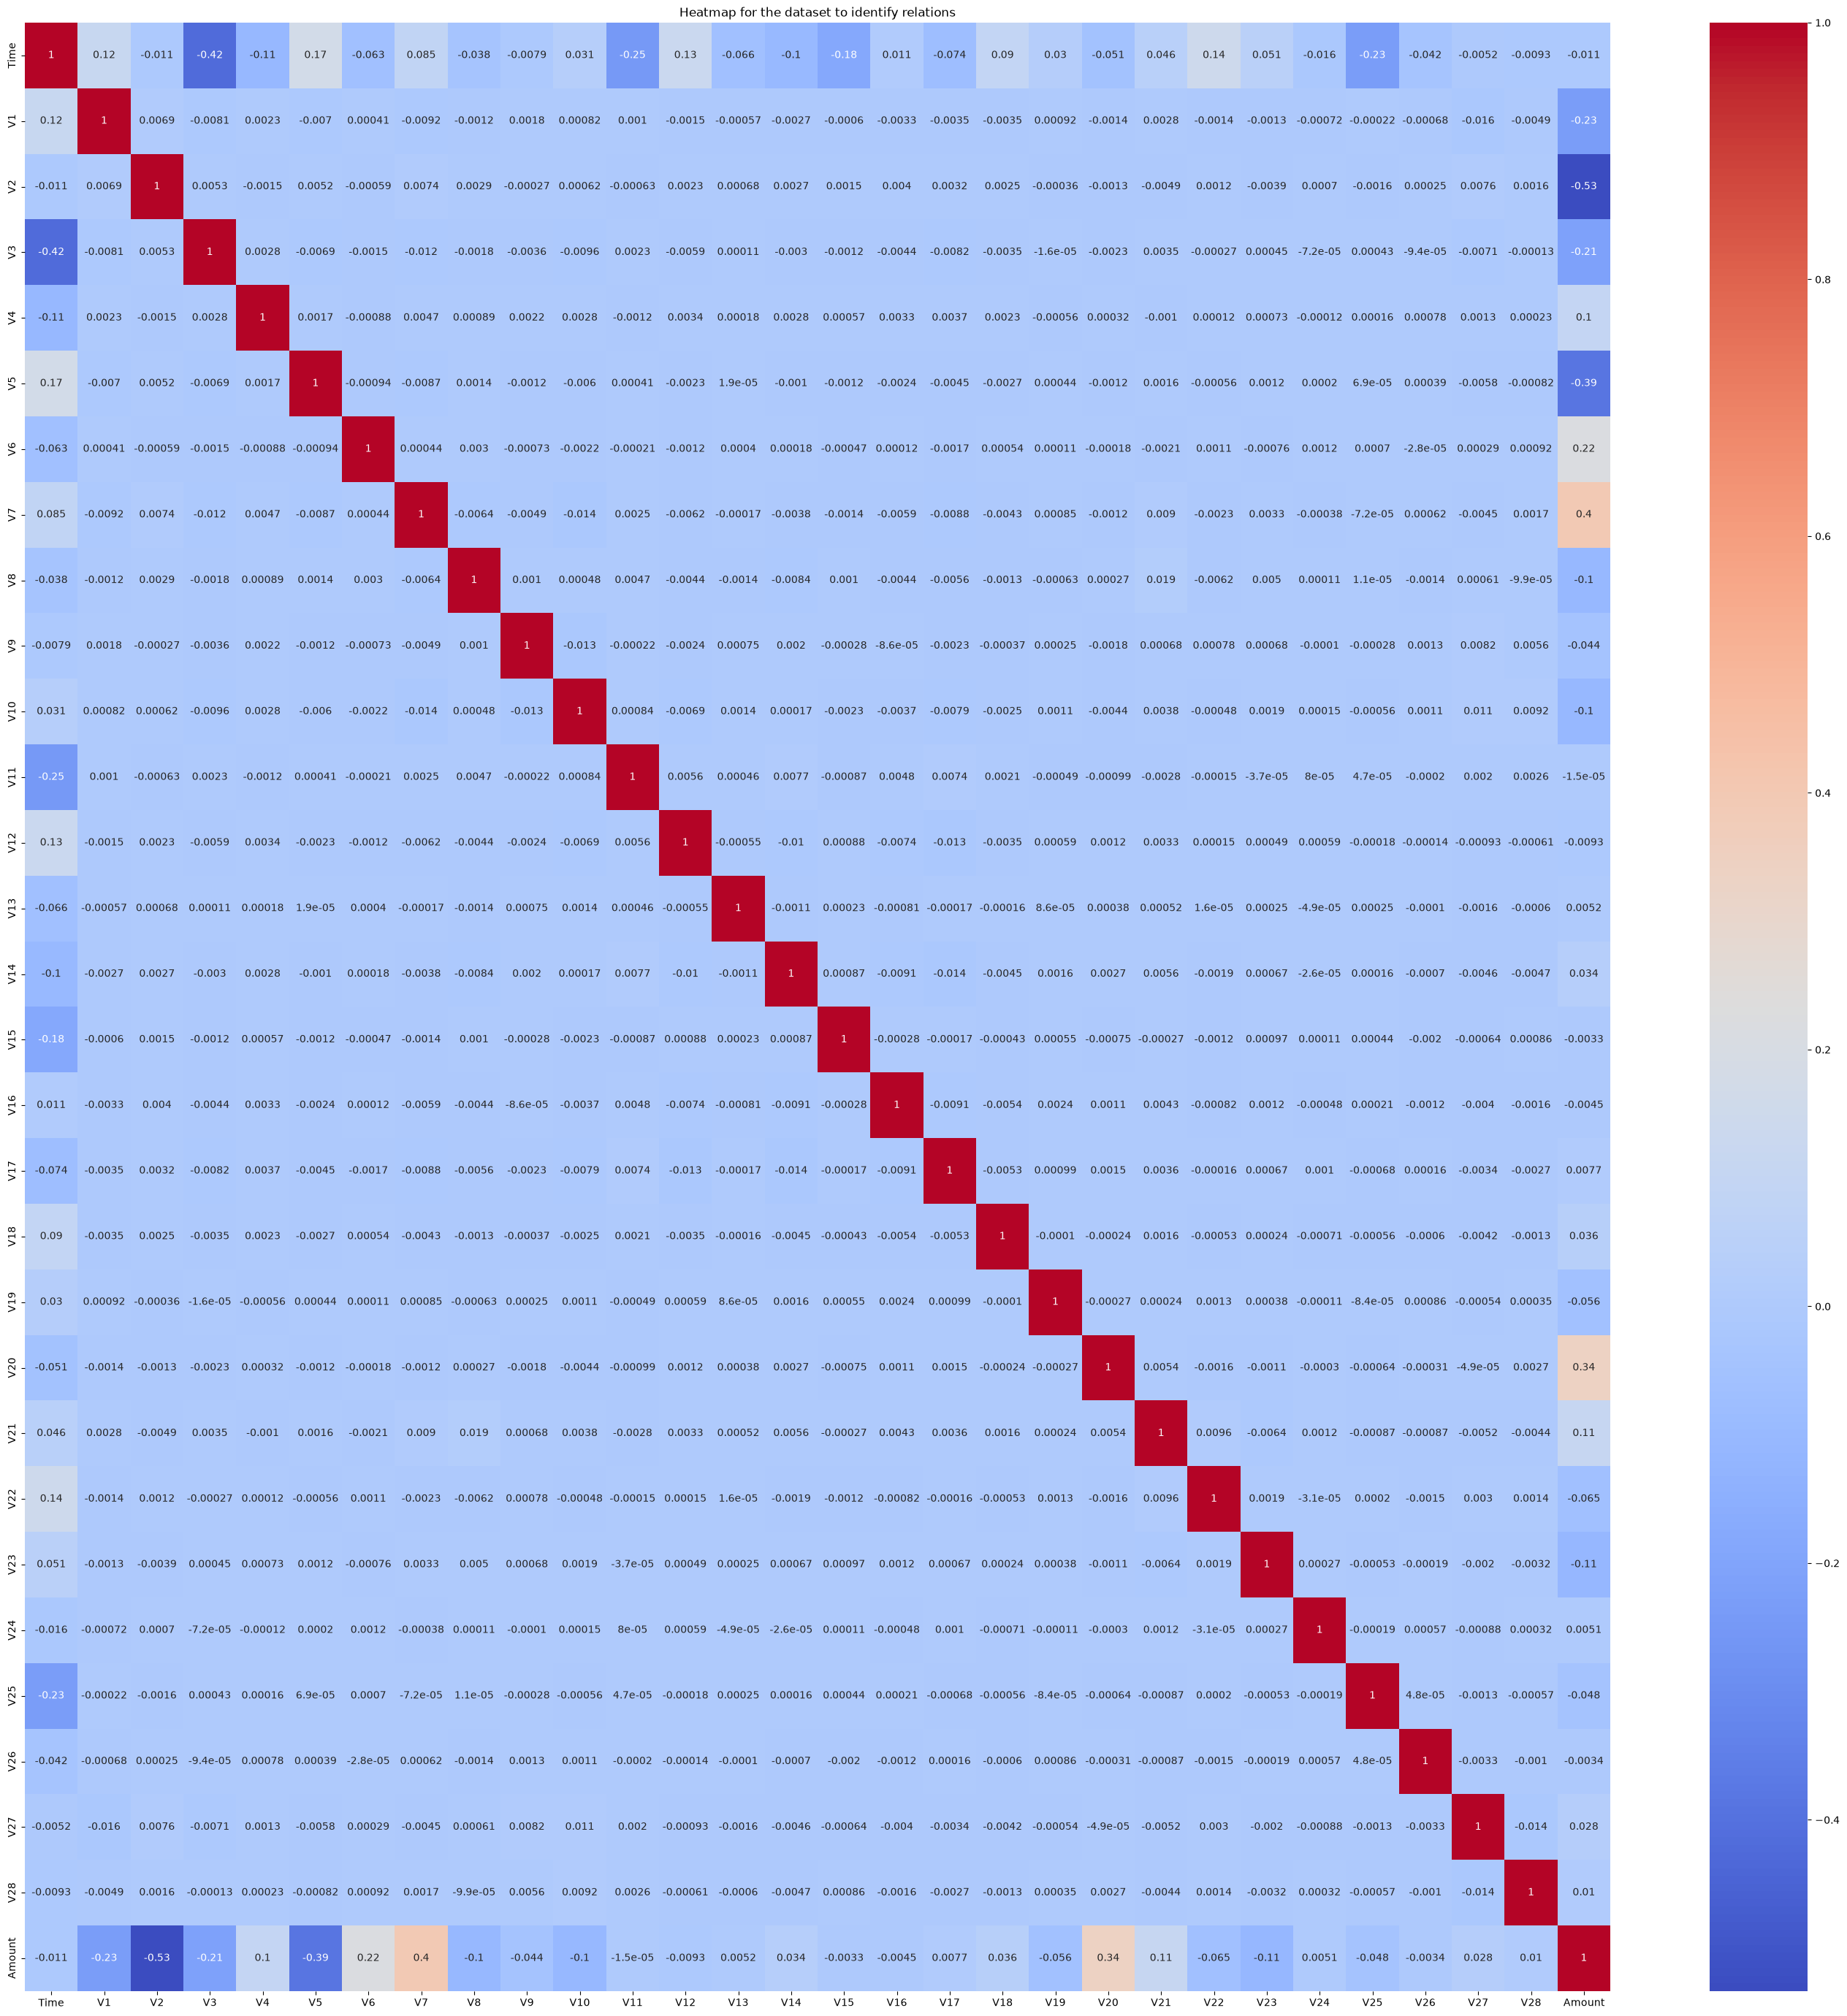

In [16]:
corr = dfcopy.select_dtypes(include="float64").corr()

plt.figure(figsize=(35,35))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Heatmap for the dataset to identify relations")
plt.show()

Based on the heatmap there are no significant relations between the columns. The bare minimum notable realtions are as follows:

- amount / v7 = 0.4
- amount / v20 = 0.34
- amount / v2 = -0.53
- v3 / time = -0.42

## 5. Preparing the data for training the logistic regression model

In [17]:
X = dfcopy.drop("Class", axis=1)
y = dfcopy["Class"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

model = LogisticRegression(max_iter=2000, class_weight="balanced")

model.fit(X_train, y_train)

(226980, 30)
(56746, 30)
(226980,)
(56746,)


C:\Users\tusha\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

## 6. Checking the metrics of the model

Accuracy score:  0.9765269798752335
confusion matrix: 
 [[55333  1323]
 [    9    81]]
Classification report: 
                precision    recall  f1-score   support

           0       1.00      0.98      0.99     56656
           1       0.06      0.90      0.11        90

    accuracy                           0.98     56746
   macro avg       0.53      0.94      0.55     56746
weighted avg       1.00      0.98      0.99     56746

ROC AUC score:  0.9728814639618438


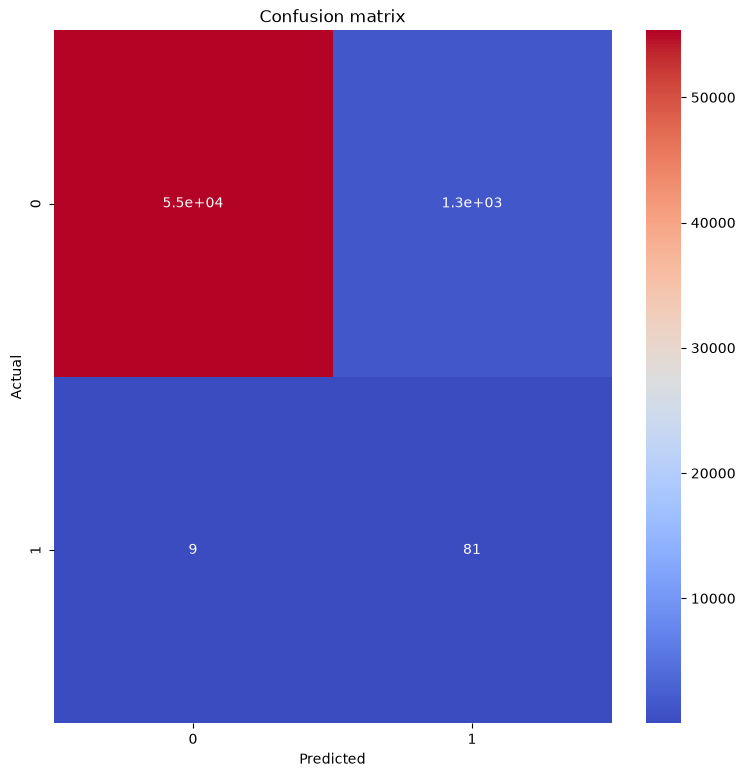

In [21]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy score: ", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("confusion matrix: \n", cm)

print("Classification report: \n ", classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC AUC score: ", roc_auc)

plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, cmap="coolwarm")
plt.title("Confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 7. Predicting values form the model to check the result 

In [22]:
# testing the model after class weight balance with a not fraud dataframe

# Define the 30 features exactly as your model expects them
features = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"]

# Normal transaction data based right on your dataset's medians
normal_data = {
    "Time": [84692.5],  # 50% (Median) Time
    "Amount": [22.0],  # 50% (Median) Amount
}

# Fill V1 through V28 with values close to their medians (roughly 0)
for i in range(1, 29):
    normal_data[f"V{i}"] = [0.01]

# Create the normal demo DataFrame
df_normal_demo = pd.DataFrame(normal_data, columns=features)

# Display the full DataFrame
print("--- Normal Transaction Demo DataFrame --- \n")
print(df_normal_demo)

predictions = model.predict(df_normal_demo)
probabilities = model.predict_proba(df_normal_demo)

print("Prediction: ", predictions)
print("Probabilities: ", probabilities)

--- Normal Transaction Demo DataFrame --- 

      Time    V1    V2    V3    V4    V5    V6    V7    V8    V9  ...   V20  \
0  84692.5  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  ...  0.01   

    V21   V22   V23   V24   V25   V26   V27   V28  Amount  
0  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01    22.0  

[1 rows x 30 columns]
Prediction:  [0]
Probabilities:  [[0.96460092 0.03539908]]


In [23]:
# A data point tailored to match the true signature of actual fraud cases

features = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"]

true_fraud_signature = {
    "Time": [80000.0],
    "Amount": [99.0],
}

# Real credit card fraud heavily drives specific components into negative or positive directions
for i in range(1, 29):
    if i in [4, 11, 2]:  # These V-features usually go highly positive in fraud
        true_fraud_signature[f"V{i}"] = [4.5]
    elif i in [14, 17, 12, 10, 7]:  # These go drastically negative in fraud
        true_fraud_signature[f"V{i}"] = [-6.0]
    else:
        true_fraud_signature[f"V{i}"] = [
            0.0
        ]  # Leave the rest neutral to isolate the effect

df_true_fraud = pd.DataFrame(true_fraud_signature, columns=features)

# --- Test this new point ---
predictions = model.predict(df_true_fraud)
probabilities = model.predict_proba(df_true_fraud)

print("Prediction: ", predictions)
print("Probabilities: ", probabilities)

Prediction:  [1]
Probabilities:  [[5.32190736e-10 9.99999999e-01]]


In [24]:
#subtle fraud
features = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"]

# Dialing back the intensity to catch the imbalanced model off guard
subtle_fraud_signature = {
    "Time": [80000.0],
    "Amount": [45.0],  # A more modest, regular-looking amount
}

# We lower the magnitudes so it looks borderline normal
for i in range(1, 29):
    if i in [4, 11, 2]:
        subtle_fraud_signature[f"V{i}"] = [
            1.8
        ]  # Noticeable, but not extreme positive shift
    elif i in [14, 17, 12, 10, 7]:
        subtle_fraud_signature[f"V{i}"] = [
            -2.2
        ]  # Noticeable, but not extreme negative shift
    else:
        subtle_fraud_signature[f"V{i}"] = [0.0]

df_subtle_fraud = pd.DataFrame(subtle_fraud_signature, columns=features)

# --- Test this new point ---
predictions = model.predict(df_subtle_fraud)
probabilities = model.predict_proba(df_subtle_fraud)

print("Prediction: ", predictions)
print("Probabilities: ", probabilities)

Prediction:  [1]
Probabilities:  [[0.00263916 0.99736084]]
